First Look At The Titanic Dataset

Import Data

In [1]:
import sys
sys.path.append("..")
from src.data_loader import df
import matplotlib.pyplot as plt
import seaborn as sns

Checking Dataset

In [3]:
# Shows shape of the dataset (column, rows)
print(df.shape)
print("---")

# Gives information about column types and number of values inserted in each column
print(df.info())
print("---")

# Gives brief information about the mean, mode 
print(df.describe())
print("---")

# Shows the first 5 rows in dataset
print(df.head())
print("---")

(891, 15)
---
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB
None
---
         survived      pclass         age       sibsp       parch      

Distributions of key variables

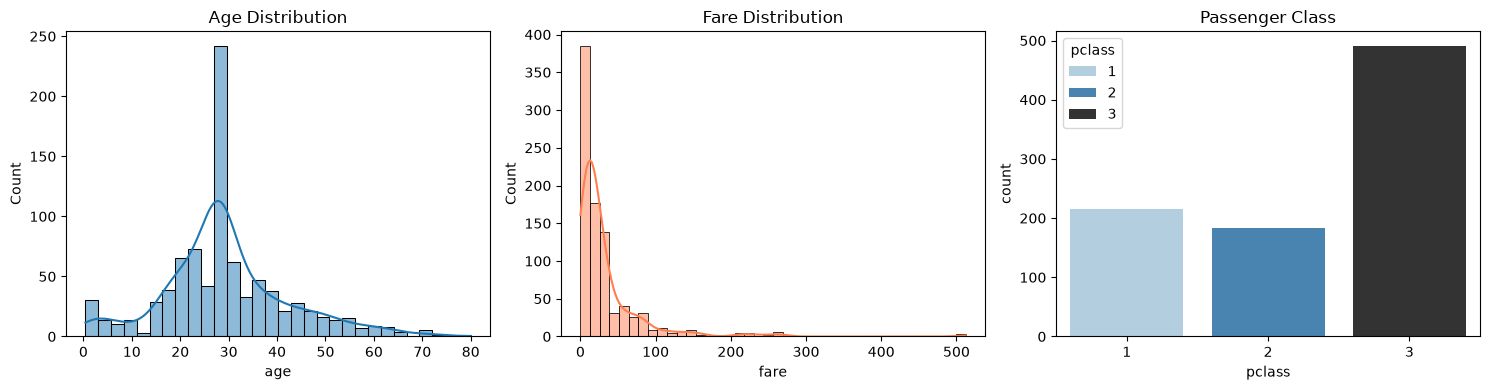

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(data=df["age"], bins=30, kde=True, ax=axes[0])
axes[0].set_title("Age Distribution")

sns.histplot(data=df["fare"], bins=40, kde=True, ax=axes[1], color="coral")
axes[1].set_title("Fare Distribution")

sns.countplot(x="pclass", data=df, ax=axes[2], palette="Blues_d", hue="pclass")
axes[2].set_title("Passenger Class")

plt.tight_layout()
plt.show()


Findings on distributions of key variables

Age is roughly bell-shaped, centered around 28. Most passengers are 20–40.
Fare is heavily right-skewed — most paid cheaply, a few paid enormous amounts (First Class).
Third Class had almost double the passengers of First and Second combined.

Overall survival rate

In [ ]:
print(df["survived"].value_counts())
print(f"Survival rate: {df["survived"].mean():.1%}")

survived
0    549
1    342
Name: count, dtype: int64
Survival rate: 38.4%


Only 38.4% survived. Now the question is: Who survived ?

Survival by sex

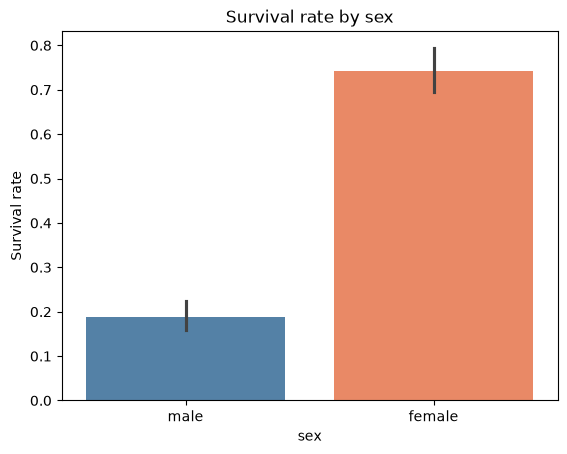

sex
female    74.2
male      18.9
Name: survived, dtype: float64

In [ ]:
sns.barplot(data=df, x="sex", y="survived", palette=["steelblue", "coral"], hue="sex")
plt.title("Survival rate by sex")
plt.ylabel("Survival rate")
plt.show()

df.groupby("sex")["survived"].mean().round(3) * 100

Women survived at 74% rate and men at 19. it is clear that the "women and children first policy was implemented"

Survival by passenger class

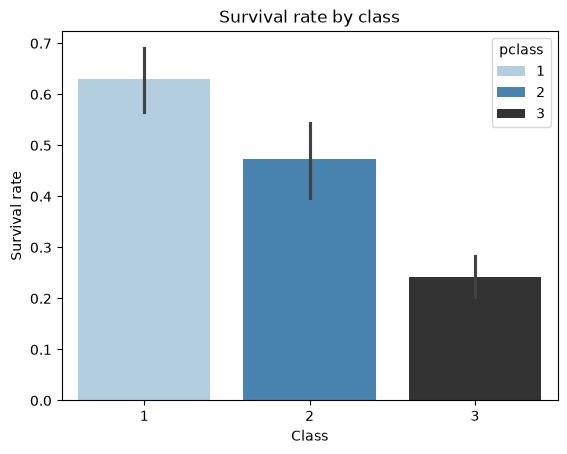

pclass
1    62.962963
2    47.282609
3    24.236253
Name: survived, dtype: float64

In [ ]:
sns.barplot(data=df, x="pclass", y="survived", hue="pclass", palette="Blues_d")
plt.title("Survival rate by class")
plt.ylabel("Survival rate")
plt.xlabel("Class")
plt.show()

df.groupby("pclass")["survived"].mean() * 100

It is visible that also passanger class's had a significant effect on if they survived or not, as it is visible via the data, both second and third class survival rate combined barely reachs the first class survival rate alone. First class passengers were 2.6× more likely to survive than third class. Wealth mattered enormously.

Sex and class together

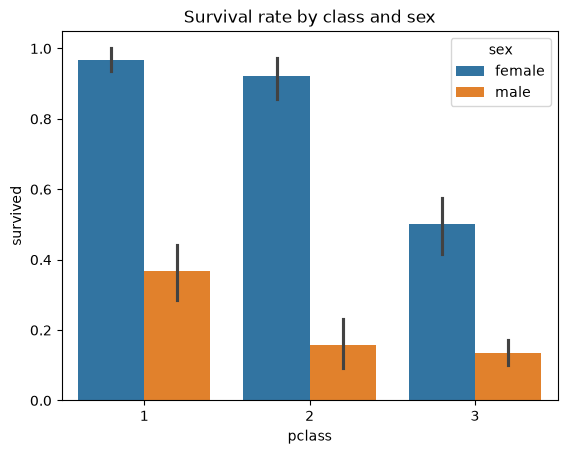

pclass  sex   
1       female    96.808511
        male      36.885246
2       female    92.105263
        male      15.740741
3       female    50.000000
        male      13.544669
Name: survived, dtype: float64

In [ ]:
sns.barplot(data=df, x="pclass", y="survived", hue="sex")
plt.title("Survival rate by class and sex")
plt.show()

df.groupby(["pclass", "sex"])["survived"].mean() * 100

First-class women had a 96.8% survival rate. Third-class men had 13.5%. The gap is staggering. Also notice: even Third Class women (50%) did better than First Class men (37%).

Age and survival

C:\Users\sobha\AppData\Local\Temp\ipykernel_15256\1952687823.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[1].set_xticklabels(["Died", "Survived"])


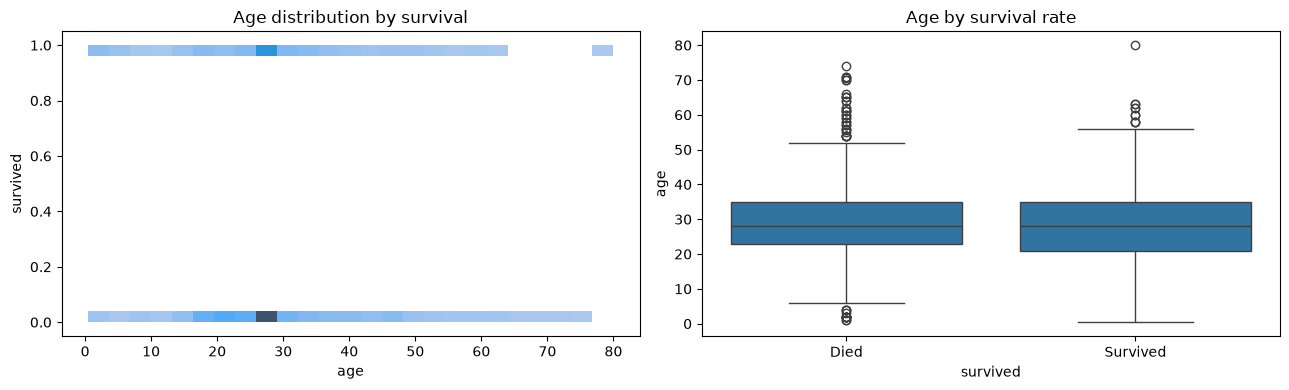

survived
0    28.0
1    28.0
Name: age, dtype: float64

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.histplot(data=df, x="age", y="survived", bins=25, multiple="stack", ax=axes[0])
axes[0].set_title("Age distribution by survival")

sns.boxplot(data=df, x="survived", y="age", ax=axes[1])
axes[1].set_title("Age by survival rate")
axes[1].set_xticklabels(["Died", "Survived"])

plt.tight_layout()
plt.show()

df.groupby("survived")["age"].median()

Age alone doesn't separate survivors from non-survivors much — except for young children, who had better survival rates. The histogram shows a bump of young child survivors.

Fare and survival

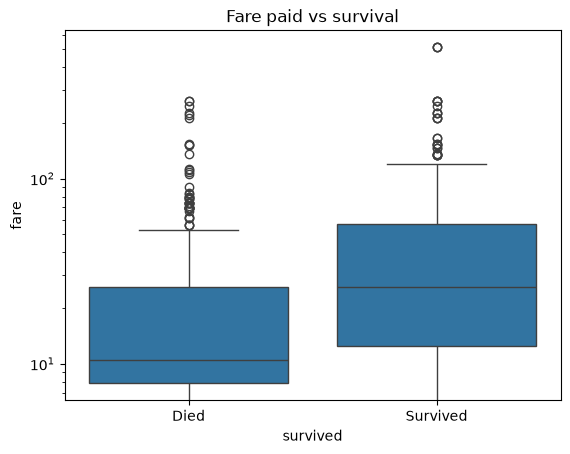

survived
0    10.5
1    26.0
Name: fare, dtype: float64

In [ ]:
sns.boxplot(data=df, x="survived", y="fare")
plt.title("Fare paid vs survival")
plt.yscale("log")
plt.xticks([0, 1], ["Died", "Survived"])
plt.show()

df.groupby("survived")["fare"].median()

Survivors paid significantly higher fares. This is partly a proxy for class — First Class passengers paid more and survived more.

Correlation heatmap

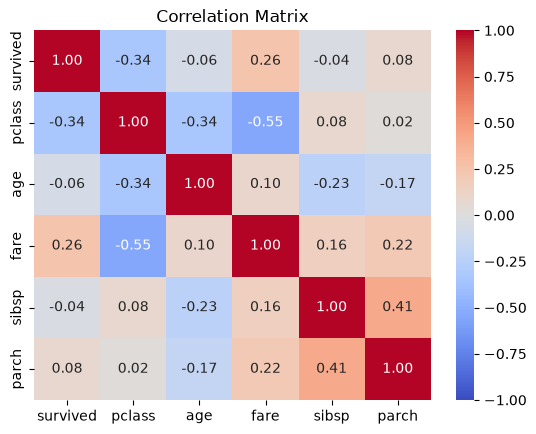

In [ ]:
numeric_cols = ["survived", "pclass", "age", "fare", "sibsp", "parch"]
corr = df[numeric_cols].corr()

sns.heatmap(data=corr, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlation Matrix")
plt.show()

pclass and fare are strongly negatively correlated (-0.55) — higher class = higher fare, makes sense
pclass and survived are negatively correlated (-0.34) — higher class number = worse survival
fare and survived positively correlated (0.26)
age barely correlates with survival (-0.07) — confirms what we saw above

 full picture in one chart


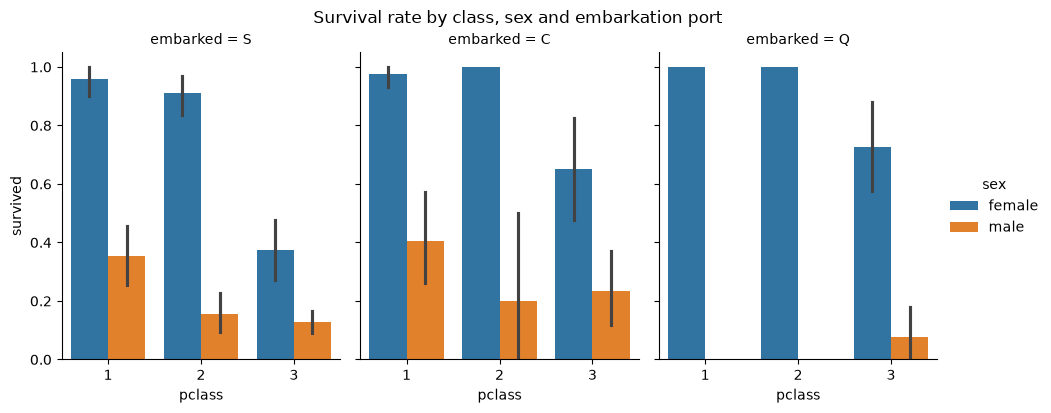

In [ ]:
sns.catplot(data=df, x="pclass", y="survived", hue="sex", col="embarked", kind="bar", height=4, aspect=0.8)
plt.suptitle("Survival rate by class, sex and embarkation port", y=1.02)
plt.show()

EDA Findings — Titanic Dataset
Dataset: 891 passengers, 38.4% overall survival rate

1. SEX is the strongest predictor:
   - Women survived at 74%, men at 19%
   - "Women and children first" policy was clearly enforced

2. CLASS was the second strongest predictor:
   - First class: 63% survival
   - Third class: 24% survival
   - Likely due to cabin location (lower decks) and lifeboat access

3. SEX × CLASS interaction:
   - First-class women: 96.8% survival — almost certain to survive
   - Third-class men: 13.5% survival — almost certain to die
   - Even third-class women (50%) outsurvived first-class men (37%)

4. AGE had little effect overall, except young children
   - No meaningful difference in median age between survivors/non-survivors

5. FARE correlates with survival (r=0.26), but is mostly a proxy for class

6. Missing data: deck column (77% missing) was dropped;
   age (20% missing) was imputed with median


Checking Missing Values In Dataset

In [ ]:
# Shows how many values we 
print(df.isna().sum())

# Shows what percentage of each column is missing
print(df.isna().mean() * 100)

Checking if there is noisy data

In [7]:
print(df["age"].max())
print(df["age"].min())
print(df["age"].mean())
print(df["age"].mode())
print(df["age"].median())

80.0
0.42
29.69911764705882
0    24.0
Name: age, dtype: float64
28.0


Result:
close to 20% of age is missing -> we should put median of age in missing values
close to 77% of deck is missing -> we should drop this column compeletly, the existing values are not enough to fill the missing ones
less than 0.5% of embarked and embark_town values combined are missing -> we use the first mode of each column to fill in the missing ones
